# Numproject 2

Groupmembers: Mats Lindegaard, Nathalie Kjelling og Olea Løvseth

We have used cursor (Claude Haiku 2) to rewrite the docstrings and fix spelling and grammatical errors

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from functions import (
    make_simple_mesh,
    make_mesh,
    plot_mesh,
    ell0__,
    spring_energy,
    spring_forces,
    total_energy,
    total_energy_jacobian,
    _boundary_ids,
    plot_strain_distribution,
)

### TASK 1

We create a simple 5-node mesh using `make_simple_mesh`. The mesh represents a small rectangular region with triangular connectivity.

In [2]:
### TASK 1 – Simple mesh

a0 = 0.01
nodes, connections = make_simple_mesh(a0)
print("Nodes:\n", nodes)
print("Connections:\n", connections)

Nodes:
 [[0.         0.        ]
 [0.01732051 0.        ]
 [0.00866025 0.005     ]
 [0.         0.01      ]
 [0.01732051 0.01      ]]
Connections:
 [[0 1]
 [0 2]
 [0 3]
 [1 2]
 [1 4]
 [2 3]
 [2 4]
 [3 4]]


### TASK 2

Oppgave 2) For å modellere elastiteten til et materiale forenkler vi materialet til et rektangel med en masse i hvert hjørne og en i sentrum som har fjærer mellom seg. Meshnetet består av massen til punktene(xy) og strekene mellom dem (edges). De allerede vedlagte funksjonene lager dette fjærsystemet og plotter det.

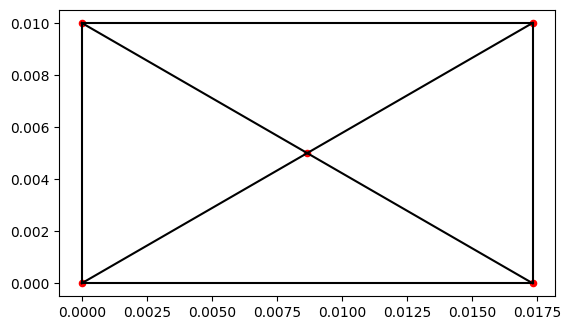

In [3]:
### TASK 2 – Plot the simple mesh

plot_mesh(nodes, connections)

### TASK 3

Oppgave 3)
Hva gjør funksjonen: def spring_energy ( xy , edges , k , ell0_ )
Funksjonen tar inn meshnetet, k (fjærkonstanten) og fjærenes hvilelengde.
Funksjonen regner ut fjæras lengde for hver fjær i systemet før den finner lengde forskjellen med fjæras hvilelengde og bruker denne lengden til å regne ut fjærenergien. Alle disse energiene plusses sammen.

Hva gjør funksjonen: spring_forces ( xy , edges , k , ell0_ ):
Funksjonen tar inn samme parametere som funksjonen over. Denne funksjonen starter også med å finne lengden mellom to masser, hvis lengden er over 0 regner den ut kreftene deretter gjøres lengden om til en vektor og legges til i forces lista på de respektive partiklene de virket på (med motsatt fortegn).

Disse funksjonene henger sammen siden kreftene på de ulike fjærene er den negative gradienten til  fjærenergi funksjonen.


In [4]:
### TASK 3 – Equilibrium lengths, energy and forces

k = 1e2
ell0_ = ell0__(nodes, connections)
print("Equilibrium lengths:", ell0_)

E0 = spring_energy(nodes, connections, k, ell0_)
print(f"Spring energy at rest: {E0:.6f}  (should be ~0)")

F0 = spring_forces(nodes, connections, k, ell0_)
print("Forces at rest (should be ~0):\n", F0)

Equilibrium lengths: [0.01732051 0.01       0.01       0.01       0.01       0.01
 0.01       0.01732051]
Spring energy at rest: 0.000000  (should be ~0)
Forces at rest (should be ~0):
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


### TASK 4

Energiminimumet til systemet tilsvarer likevekt, der den totale potensielle energien er minst mulig.
Systemet når dette punktet når den deriverte av energien med hensyn på partikkelposisjonene er lik null.

Dette betyr at netto kraft på hver partikkel er null, siden kreftene er gitt av den negative gradienten til energien.
Når kreftene balanserer på denne måten er systemet i likevekt og det er ingen netto bevegelse.

fjerner y-bindingene på venstre og høyre side for å tillate sammentrekning. Vi legger også til en binding som fester bunnodene i y-retningen for å hindre stivlegeme-bevegelse. Utover dette er oppsettet det samme som gitt i oppgaven. Denne endringen ble gjort for å fjerne noen mulige feil 

In [5]:
### TASK 4 – Boundary IDs and total energy

ids_left, ids_right, ids_bottom = _boundary_ids(nodes)
print("Left boundary nodes: ", ids_left)
print("Right boundary nodes:", ids_right)
print("Bottom boundary nodes:", ids_bottom)

K = 1e4
Lx0 = nodes[:, 0].max() - nodes[:, 0].min()
f_test = 0.05
Lx_plate = Lx0 * (1 + f_test)

E_total = total_energy(
    nodes.flatten(), connections, k, K, ell0_, Lx_plate, nodes, ids_left, ids_right, ids_bottom
)
print(f"\nTotal energy at rest (f={f_test}): {E_total:.6f}")

Left boundary nodes:  [0 3]
Right boundary nodes: [1 4]
Bottom boundary nodes: [0 1]

Total energy at rest (f=0.05): 0.007500


### TASK 5

In [6]:
### TASK 5 – Strain distribution on the simple mesh

plot_strain_distribution(
    stretch_factors=[0.0, 0.0001, 0.01, 0.05, 0.1, 0.3, 0.5],
    k=1e2,
    K=1e4,
    nodes_r0=nodes,
    task5 = True,
    connections=connections,
)

x0: 0.017320508075688773, y0: 0.01


np.float64(-0.23734891074040626)

### TASK 6

x0: 0.017320508075688773, y0: 0.01


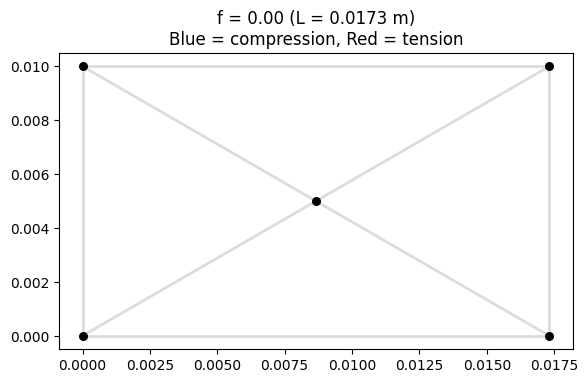

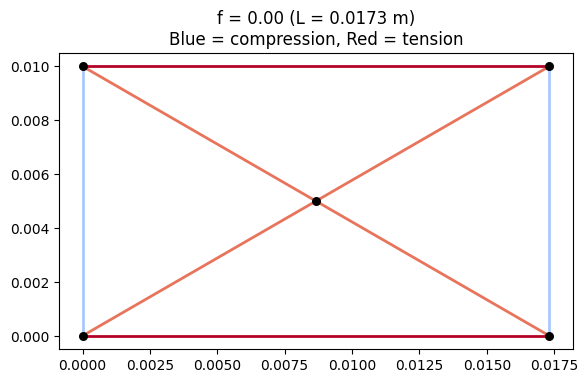

f = 0.0001 | E = 461.89 N/m² | ν = 0.3289


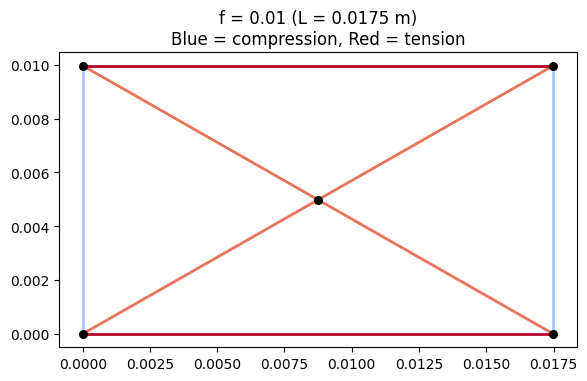

f = 0.0100 | E = 462.62 N/m² | ν = 0.3268


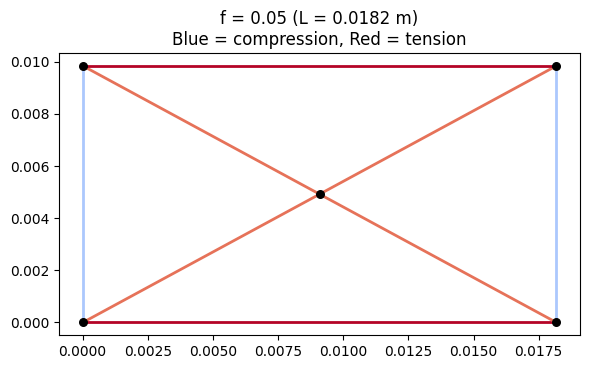

f = 0.0500 | E = 465.47 N/m² | ν = 0.3183


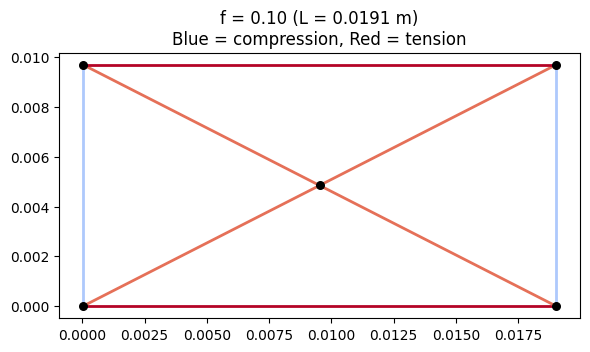

f = 0.1000 | E = 468.75 N/m² | ν = 0.3079


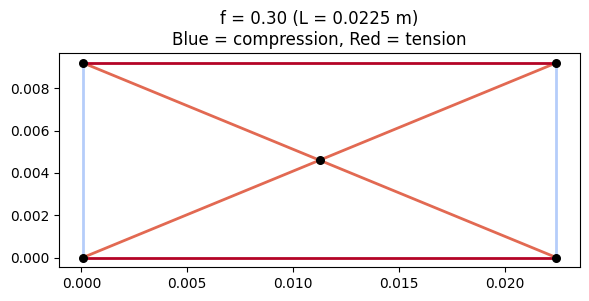

f = 0.3000 | E = 479.31 N/m² | ν = 0.2695


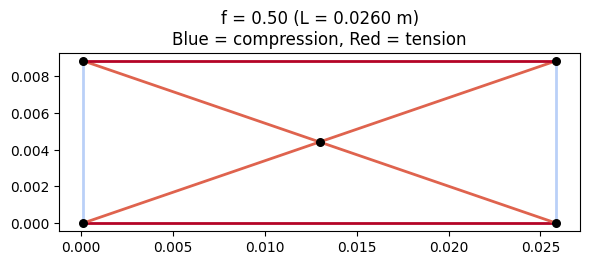

f = 0.5000 | E = 486.76 N/m² | ν = 0.2373


np.float64(-0.23734891074040626)

In [7]:
### TASK 6 – Macroscopic strain ratio (Poisson-like)

plot_strain_distribution(
    stretch_factors=[0.0, 0.0001, 0.01, 0.05, 0.1, 0.3, 0.5],
    k=1e2,
    K=1e4,
    task6=True,
    nodes_r0=nodes,
    connections=connections,
)

### TASK 7

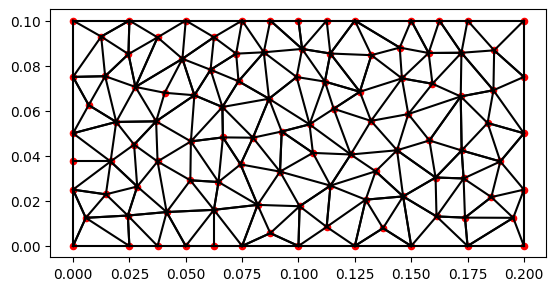

In [8]:
### TASK 7 – Larger mesh generated with make_mesh

nodes_r, connections_r = make_mesh(0.2, 0.1, 100)
plot_mesh(nodes_r, connections_r)

No task called
x0: 0.2, y0: 0.1


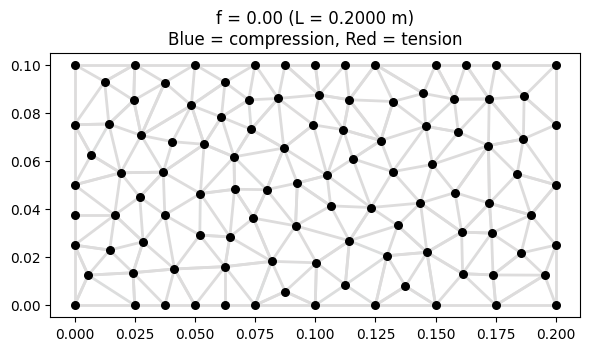

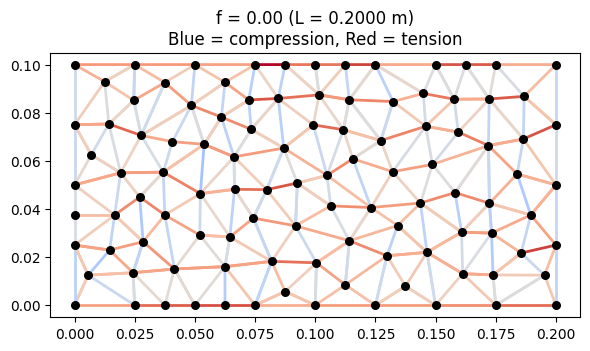

f = 0.0001 | E = 158.44 N/m² | ν = 0.1983


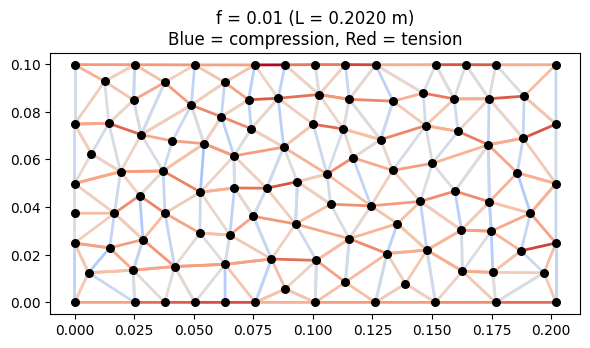

f = 0.0100 | E = 159.25 N/m² | ν = 0.2019


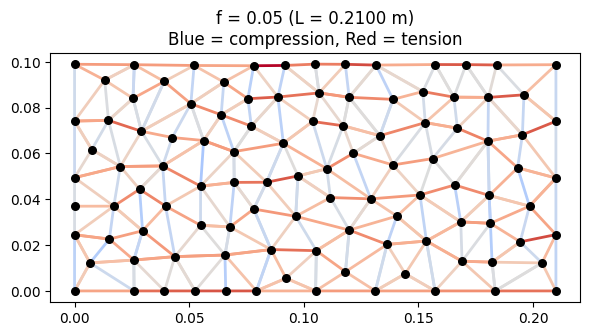

f = 0.0500 | E = 162.35 N/m² | ν = 0.2144


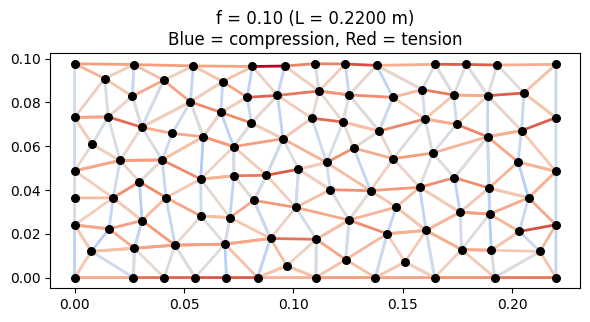

f = 0.1000 | E = 165.86 N/m² | ν = 0.2268


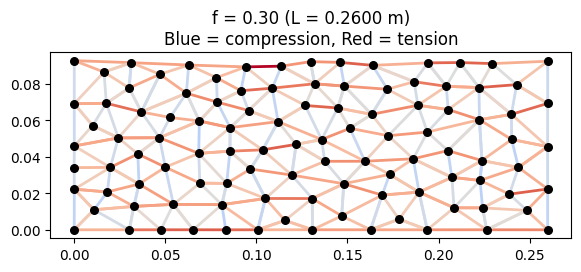

f = 0.3000 | E = 177.17 N/m² | ν = 0.2392


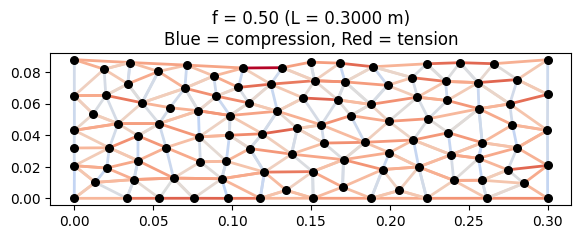

f = 0.5000 | E = 185.62 N/m² | ν = 0.2447


np.float64(-0.2447078133105968)

In [9]:
# Strain distribution on the large mesh
plot_strain_distribution(
    stretch_factors=[0.0, 0.0001, 0.01, 0.05, 0.1, 0.3, 0.5],
    k=1e2,
    K=1e4,
    nodes_r0=nodes_r,
    connections=connections_r,
)

# Strain ratio on the large mesh
plot_strain_distribution(
    stretch_factors=[0.0, 0.0001, 0.01, 0.05, 0.1, 0.3, 0.5],
    k=1e2,
    K=1e4,
    task6=True,
    nodes_r0=nodes_r,
    connections=connections_r,
)

### TASK 8

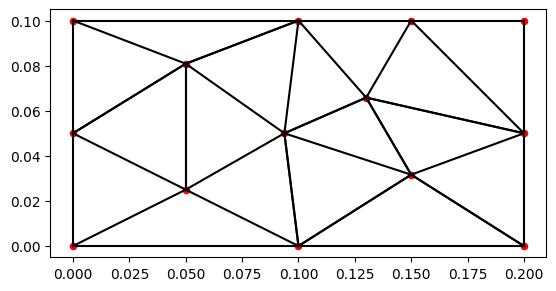

Mesh with 10 nodes:
x0: 0.2, y0: 0.1


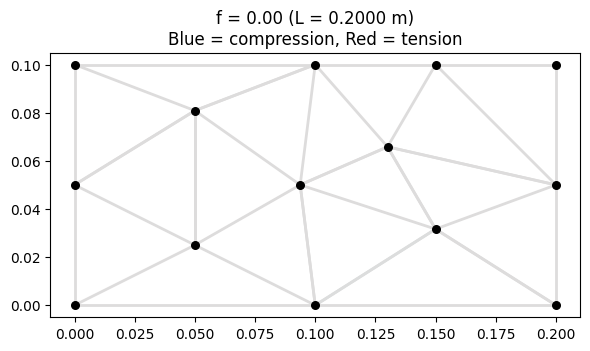

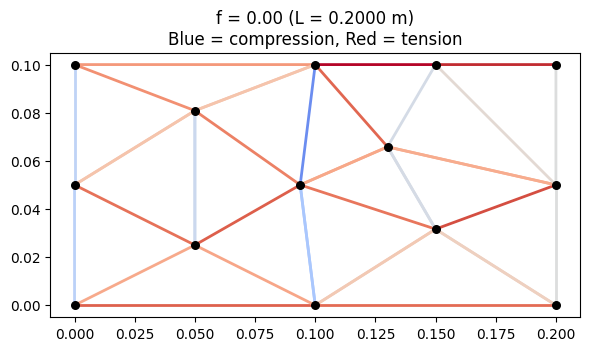

f = 0.0001 | E = 317.83 N/m² | ν = -0.0012


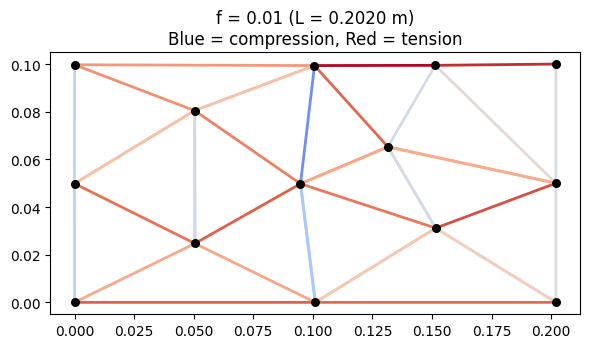

f = 0.0100 | E = 319.97 N/m² | ν = 0.0122


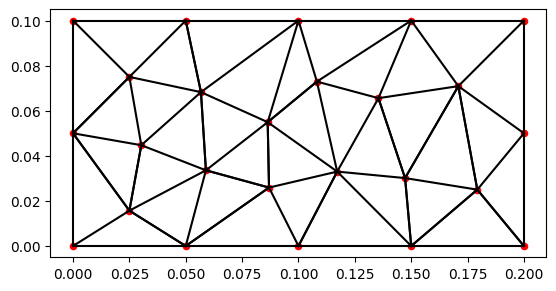

Mesh with 20 nodes:
x0: 0.2, y0: 0.1


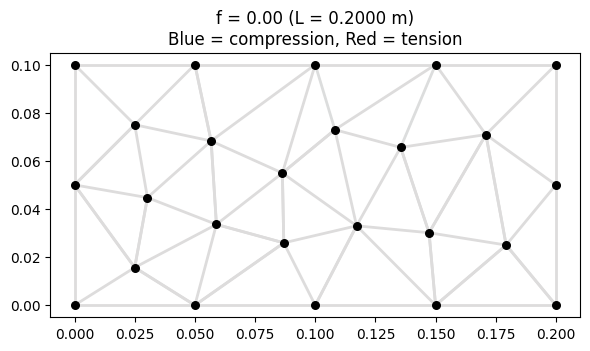

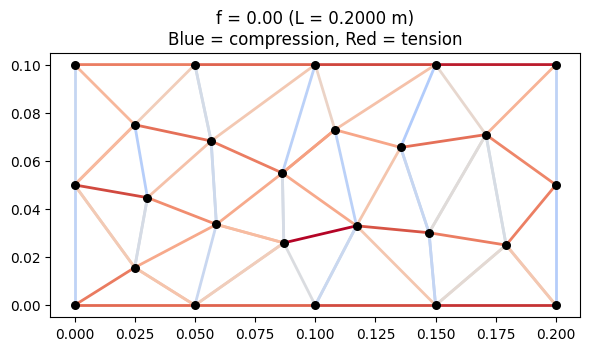

f = 0.0001 | E = 180.22 N/m² | ν = 0.2043


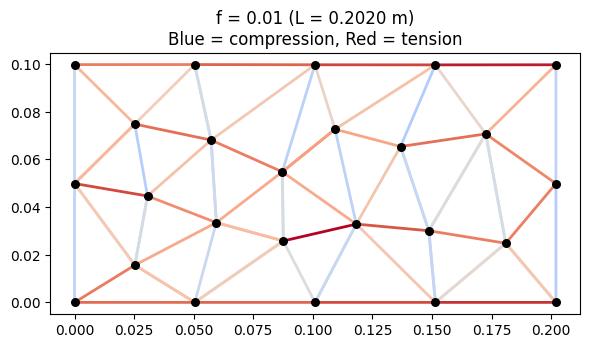

f = 0.0100 | E = 180.80 N/m² | ν = 0.2066


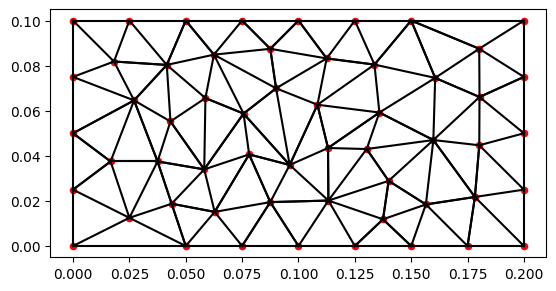

Mesh with 50 nodes:
x0: 0.2, y0: 0.1


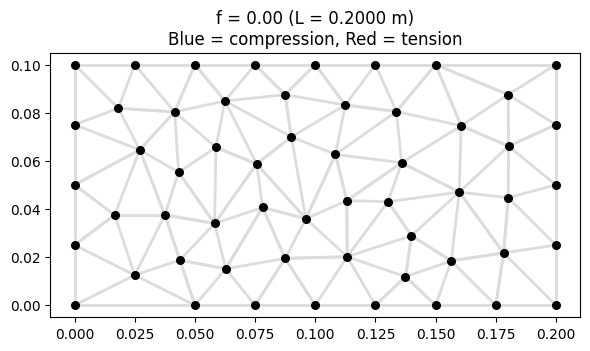

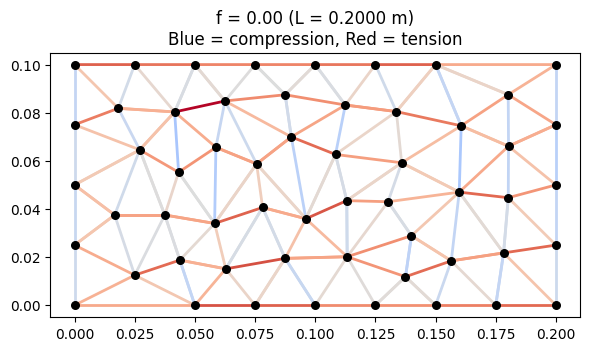

f = 0.0001 | E = 182.09 N/m² | ν = 0.2186


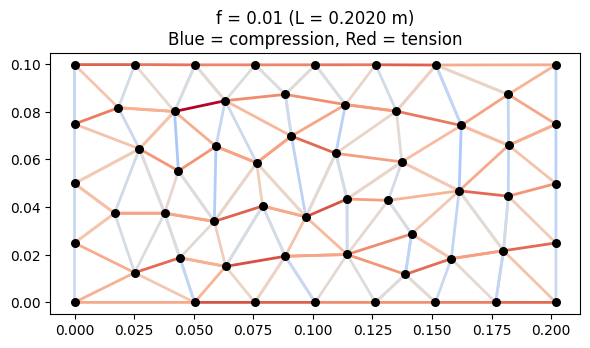

f = 0.0100 | E = 182.86 N/m² | ν = 0.2217


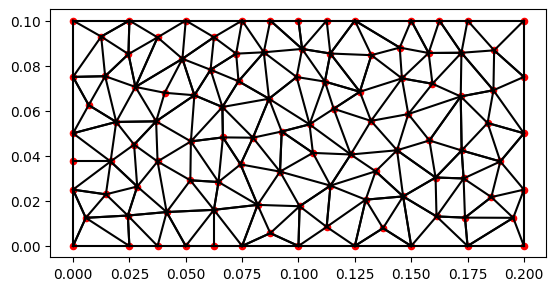

Mesh with 100 nodes:
x0: 0.2, y0: 0.1


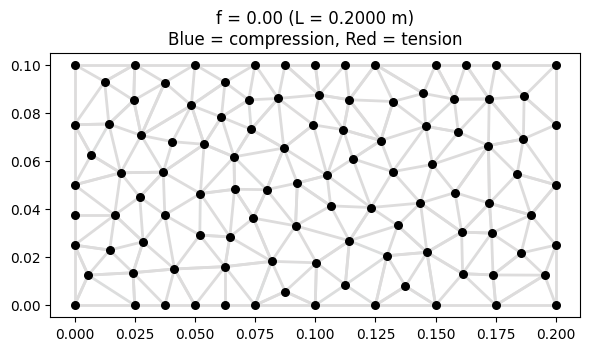

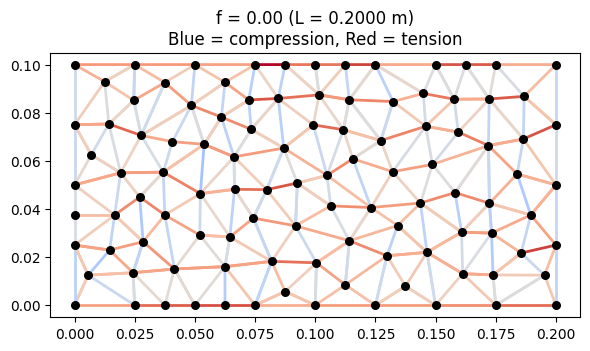

f = 0.0001 | E = 158.44 N/m² | ν = 0.1983


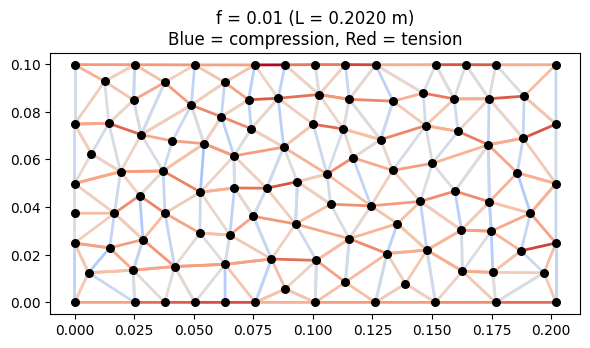

f = 0.0100 | E = 159.25 N/m² | ν = 0.2019


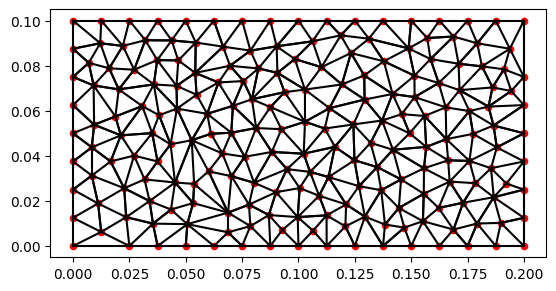

Mesh with 200 nodes:
x0: 0.2, y0: 0.1


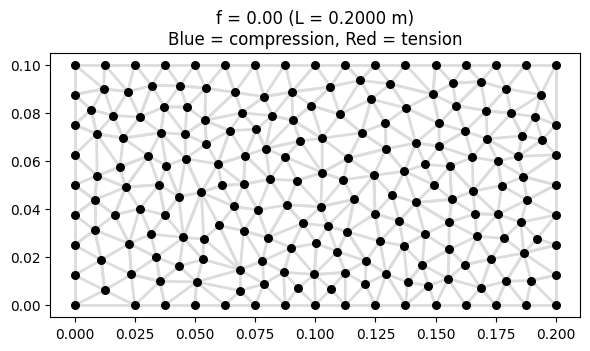

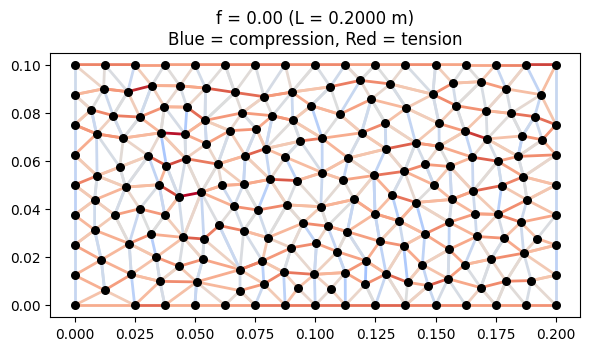

f = 0.0001 | E = 153.95 N/m² | ν = 0.2401


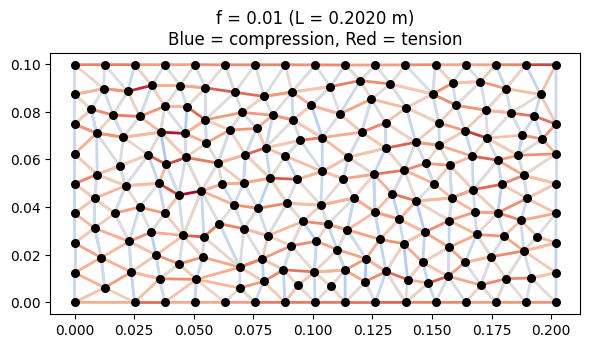

f = 0.0100 | E = 154.66 N/m² | ν = 0.2420


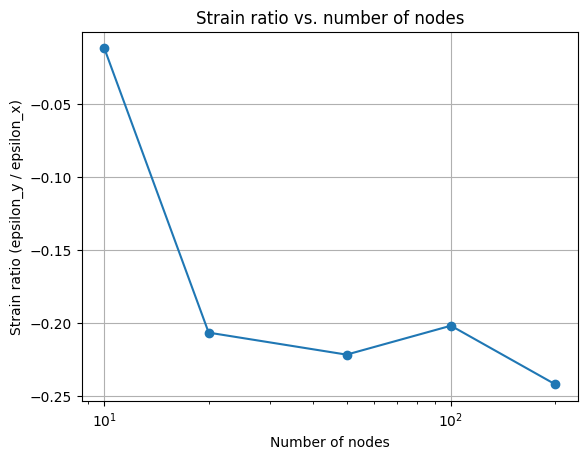

In [11]:
epsilons = []
E_measureds = []
for nodes_nr in [10, 20, 50, 100, 200]:
    nodes_r, connections_r = make_mesh(0.2, 0.1, nodes_nr)
    plot_mesh(nodes_r, connections_r)
    print(f"Mesh with {nodes_nr} nodes:")
    epsilon = plot_strain_distribution(
        stretch_factors=[0.0, 0.0001, 0.01],
        k=1e2,
        K=1e4,
        task6=True,
        nodes_r0=nodes_r,
        connections=connections_r
    )
    epsilons.append(epsilon)

plt.plot([10, 20, 50, 100, 200], epsilons, marker='o')
plt.xscale('log')
plt.xlabel('Number of nodes')   
plt.ylabel('Strain ratio (epsilon_y / epsilon_x)')
plt.title('Strain ratio vs. number of nodes')
plt.grid(True)
plt.show()

